In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
!pip install matplotlib
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
!pip install scikit-learn seaborn
print("✅ All imports loaded")

  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl (8.7 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl (10.8 MB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [

In [29]:
import tensorflow as tf
print(tf.__version__)
import keras
print(keras.__version__)

2.19.0
3.12.1


In [31]:
import tensorflow as tf
import numpy as np
from PIL import Image
import json, os

with open('class_names.json', 'r') as f:
    class_names = json.load(f)

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test on real image
class_folder = os.path.join('val_dataset', 'Tomato_Late_blight')
img_name = [f for f in os.listdir(class_folder) if not f.startswith('.')][0]
img_path = os.path.join(class_folder, img_name)

img = Image.open(img_path).resize((224, 224))
img_array = np.expand_dims(np.array(img).astype('float32'), 0)

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]['index'])

print(f"Predicted: {class_names[np.argmax(pred)]}")
print(f"Confidence: {np.max(pred):.4f}")

Predicted: Tomato_Late_blight
Confidence: 0.9435


In [32]:
import tensorflow as tf
import numpy as np
from PIL import Image
import json, os

with open('class_names.json', 'r') as f:
    class_names = json.load(f)

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Evaluate on full validation set
y_true = []
y_pred = []
total = 0
correct = 0

for i, class_name in enumerate(class_names):
    class_folder = os.path.join('val_dataset', class_name)
    images = [f for f in os.listdir(class_folder) if not f.startswith('.')]
    
    for img_name in images:
        img_path = os.path.join(class_folder, img_name)
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        img_array = np.expand_dims(np.array(img).astype('float32'), 0)
        
        interpreter.set_tensor(input_details[0]['index'], img_array)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details[0]['index'])
        
        predicted = np.argmax(pred)
        y_true.append(i)
        y_pred.append(predicted)
        
        if predicted == i:
            correct += 1
        total += 1
    
    print(f"Done: {class_name} ({len(images)} images)")

accuracy = correct / total
print(f"\nTotal images: {total}")
print(f"Correct: {correct}")
print(f"Validation Accuracy: {accuracy:.4f}")

Done: Pepper__bell___Bacterial_spot (250 images)
Done: Pepper__bell___healthy (370 images)
Done: Potato___Early_blight (250 images)
Done: Potato___Late_blight (250 images)
Done: Potato___healthy (38 images)
Done: Tomato_Bacterial_spot (532 images)
Done: Tomato_Early_blight (250 images)
Done: Tomato_Late_blight (478 images)
Done: Tomato_Leaf_Mold (237 images)
Done: Tomato_Septoria_leaf_spot (443 images)
Done: Tomato_Spider_mites_Two_spotted_spider_mite (419 images)
Done: Tomato__Target_Spot (351 images)
Done: Tomato__Tomato_YellowLeaf__Curl_Virus (803 images)
Done: Tomato__Tomato_mosaic_virus (94 images)
Done: Tomato_healthy (398 images)

Total images: 5163
Correct: 4974
Validation Accuracy: 0.9634


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.99      0.98       250
                     Pepper__bell___healthy       0.99      0.99      0.99       370
                      Potato___Early_blight       0.99      0.99      0.99       250
                       Potato___Late_blight       0.98      0.97      0.98       250
                           Potato___healthy       0.88      0.97      0.93        38
                      Tomato_Bacterial_spot       0.98      0.96      0.97       532
                        Tomato_Early_blight       0.98      0.78      0.87       250
                         Tomato_Late_blight       0.98      0.97      0.97       478
                           Tomato_Leaf_Mold       0.99      0.97      0.98       237
                  Tomato_Septoria_leaf_spot       0.94      0.97      0.95       443
Tomato_Spider_mites_Two_spotted_spider_mite       0.95      0.92

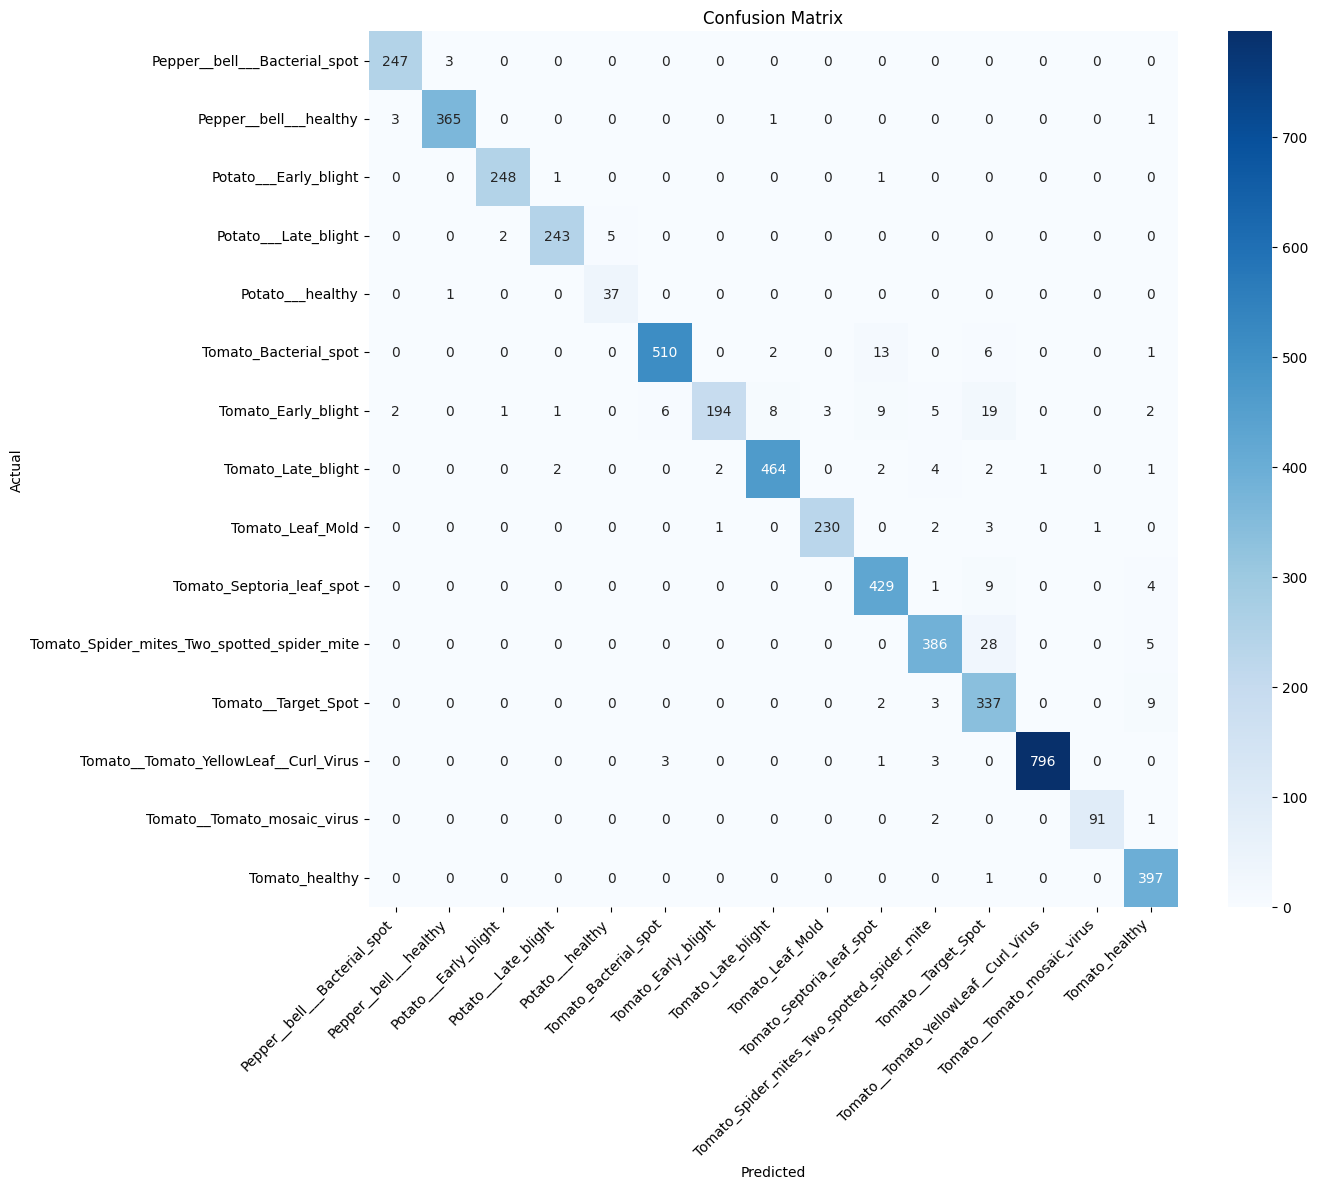

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

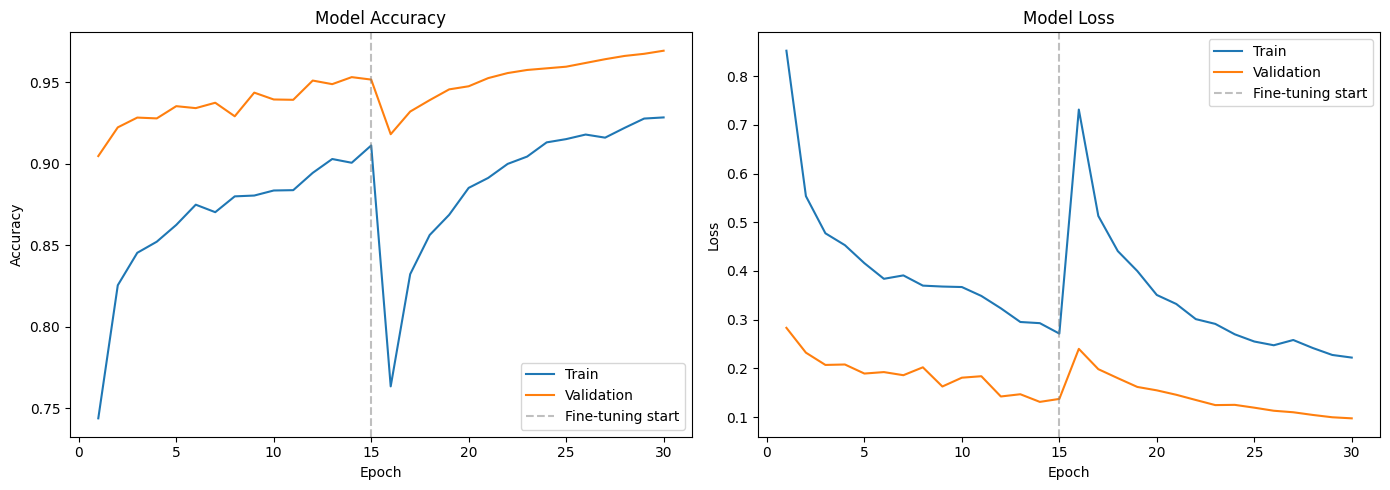

In [39]:
import matplotlib.pyplot as plt

# Phase 1 data (from your training output)
p1_acc = [0.7438, 0.8254, 0.8453, 0.8521, 0.8624, 0.8748, 0.8702, 0.8799, 0.8804, 0.8835, 0.8837, 0.8943, 0.9028, 0.9005, 0.9111]
p1_val_acc = [0.9046, 0.9222, 0.9282, 0.9277, 0.9352, 0.9340, 0.9373, 0.9290, 0.9435, 0.9393, 0.9391, 0.9509, 0.9487, 0.9530, 0.9515]
p1_loss = [0.8524, 0.5537, 0.4774, 0.4530, 0.4160, 0.3839, 0.3909, 0.3699, 0.3680, 0.3670, 0.3487, 0.3233, 0.2952, 0.2928, 0.2714]
p1_val_loss = [0.2832, 0.2322, 0.2070, 0.2079, 0.1893, 0.1923, 0.1859, 0.2021, 0.1627, 0.1808, 0.1838, 0.1422, 0.1468, 0.1311, 0.1372]

# Phase 2 data (from your training output)
p2_acc = [0.7634, 0.8322, 0.8562, 0.8686, 0.8851, 0.8912, 0.8998, 0.9043, 0.9130, 0.9150, 0.9178, 0.9159, 0.9219, 0.9276, 0.9283]
p2_val_acc = [0.9180, 0.9319, 0.9389, 0.9455, 0.9474, 0.9524, 0.9555, 0.9574, 0.9584, 0.9594, 0.9617, 0.9640, 0.9660, 0.9673, 0.9692]
p2_loss = [0.7315, 0.5130, 0.4408, 0.3999, 0.3507, 0.3322, 0.3011, 0.2913, 0.2699, 0.2551, 0.2474, 0.2582, 0.2418, 0.2275, 0.2221]
p2_val_loss = [0.2400, 0.1983, 0.1798, 0.1618, 0.1548, 0.1457, 0.1350, 0.1245, 0.1250, 0.1192, 0.1129, 0.1098, 0.1043, 0.0995, 0.0973]

# Combine
acc = p1_acc + p2_acc
val_acc = p1_val_acc + p2_val_acc
loss = p1_loss + p2_loss
val_loss = p1_val_loss + p2_val_loss
epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, acc, label='Train')
ax1.plot(epochs, val_acc, label='Validation')
ax1.axvline(x=15, color='gray', linestyle='--', alpha=0.5, label='Fine-tuning start')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, loss, label='Train')
ax2.plot(epochs, val_loss, label='Validation')
ax2.axvline(x=15, color='gray', linestyle='--', alpha=0.5, label='Fine-tuning start')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

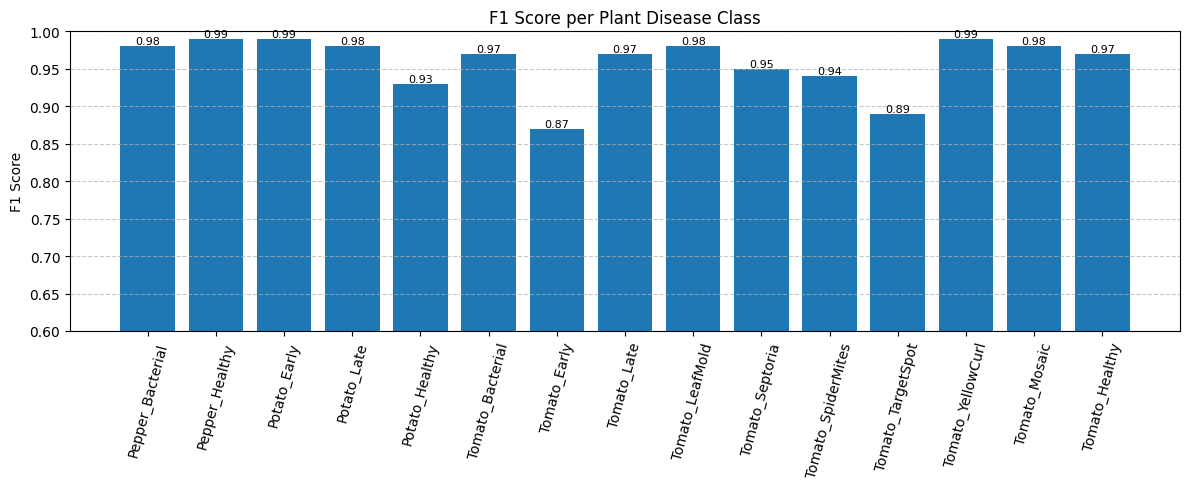

In [40]:
import matplotlib.pyplot as plt

classes = [
    "Pepper_Bacterial", "Pepper_Healthy",
    "Potato_Early", "Potato_Late", "Potato_Healthy",
    "Tomato_Bacterial", "Tomato_Early", "Tomato_Late",
    "Tomato_LeafMold", "Tomato_Septoria",
    "Tomato_SpiderMites", "Tomato_TargetSpot",
    "Tomato_YellowCurl", "Tomato_Mosaic", "Tomato_Healthy"
]

# Updated F1 scores from your actual classification report
f1_scores = [0.98, 0.99, 0.99, 0.98, 0.93, 0.97, 0.87, 0.97, 0.98, 0.95, 0.94, 0.89, 0.99, 0.98, 0.97]

plt.figure(figsize=(12, 5))
bars = plt.bar(classes, f1_scores)
plt.xticks(rotation=75)
plt.ylabel("F1 Score")
plt.title("F1 Score per Plant Disease Class")
plt.ylim(0.6, 1.0)

for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{score:.2f}", ha='center', va='bottom', fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

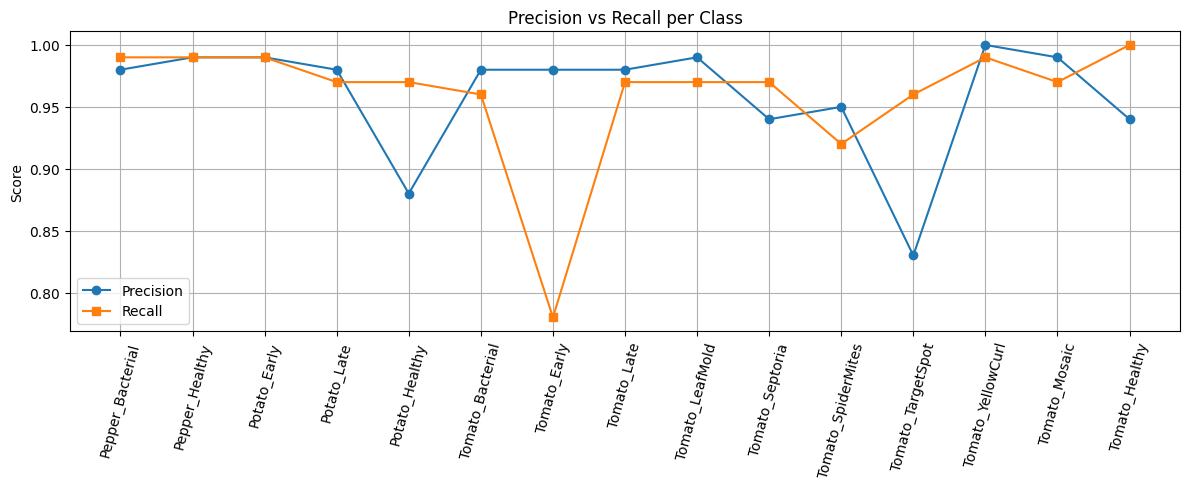

In [41]:
precision = [0.98, 0.99, 0.99, 0.98, 0.88, 0.98, 0.98, 0.98, 0.99, 0.94, 0.95, 0.83, 1.00, 0.99, 0.94]
recall    = [0.99, 0.99, 0.99, 0.97, 0.97, 0.96, 0.78, 0.97, 0.97, 0.97, 0.92, 0.96, 0.99, 0.97, 1.00]

plt.figure(figsize=(12, 5))
plt.plot(classes, precision, marker='o', label='Precision')
plt.plot(classes, recall, marker='s', label='Recall')
plt.xticks(rotation=75)
plt.ylabel("Score")
plt.title("Precision vs Recall per Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

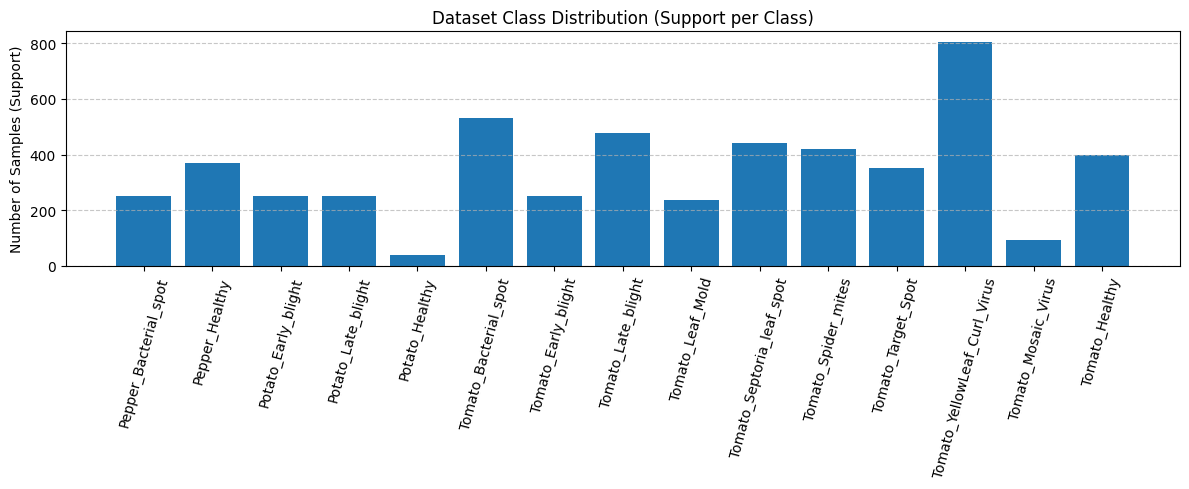

In [43]:
plt.figure(figsize=(12, 5))
plt.bar(classes, support)
plt.xticks(rotation=75)
plt.ylabel("Number of Samples (Support)")
plt.title("Dataset Class Distribution (Support per Class)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()